In [ ]:
# Удаление пропущенных значений
df = df.dropna(subset=['ds', 'y'])
df = df.sort_values('ds').reset_index(drop=True)

data_train.tail(-5) и head

Prophet – прогнозирование временных рядов от Facebook 
https://pythonlib.ru/library-theme18

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
import math #### все функции
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve
from IPython.display import display, HTML
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

from sympy import *

import mpl_toolkits.mplot3d as p3
import random
import time


from functools import partial
#from ipywidgets import interact, RadioButtons, IntSlider, FloatSlider, Dropdown, BoundedFloatText
from numpy.linalg import norm

from scipy import sparse

random.seed(42) # начальное состояние генератора случайных чисел, чтобы можно было воспроизводить результаты.

#!unzip «путь_до_архива»
#Всё извлечётся в память Colab.

In [2]:
# plotting
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

# не ЕTNA модели Prophet, TBATS, SARIMAX — модели для предсказания временных рядов
import statsmodels

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from tbats import TBATS
from prophet import Prophet
from pmdarima import auto_arima

# make plots bigger
from pylab import rcParams
rcParams['figure.figsize'] = 15, 7

In [3]:
import plotly.express as px
import statsmodels.api as sm


In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL

In [5]:
# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from tbats import TBATS
from prophet import Prophet
from pmdarima import auto_arima

In [6]:
import warnings
warnings.filterwarnings('ignore')

Prophet, TBATS, SARIMAX — модели для предсказания временных рядов

In [6]:
df2 = pd.read_csv(
    '/workspaces/pyt_begin/data_data/a10.csv'
    )

In [8]:
df2.describe()

,value
count,204.000000
mean,10.694430
std,5.956998
min,2.814520
25%,5.844095
50%,9.319345
75%,14.289964
max,29.665356


In [34]:
df2.head()

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    204 non-null    object 
 1   value   204 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.3+ KB


In [8]:
data= df2

In [9]:
# Дату уставнавливаем как индекс
data = data.set_index('date')

# Выделяем данные о продажах
data = data['value']

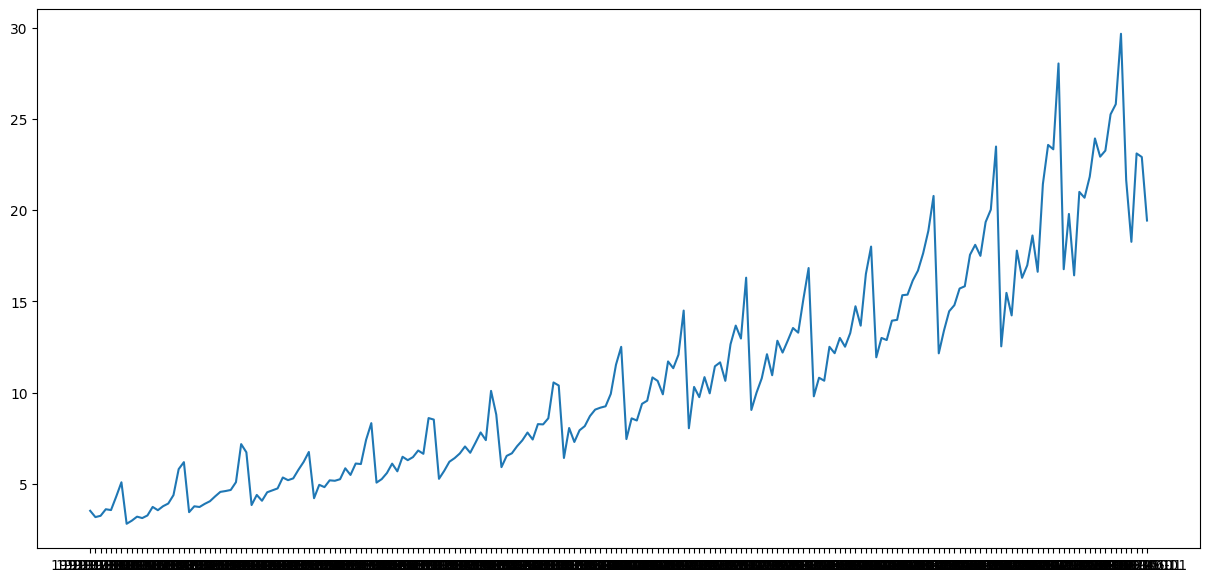

In [10]:
plt.plot(data)

In [39]:
data.head(20)

date
1991-07-01    3.526591
1991-08-01    3.180891
1991-09-01    3.252221
1991-10-01    3.611003
1991-11-01    3.565869
1991-12-01    4.306371
1992-01-01    5.088335
1992-02-01    2.814520
1992-03-01    2.985811
1992-04-01    3.204780
1992-05-01    3.127578
1992-06-01    3.270523
1992-07-01    3.737851
1992-08-01    3.558776
1992-09-01    3.777202
1992-10-01    3.924490
1992-11-01    4.386531
1992-12-01    5.810549
1993-01-01    6.192068
1993-02-01    3.450857
Name: value, dtype: float64

In [11]:
test_size = 12
data_train = data.iloc[: -test_size]
data_test  = data.iloc[-test_size:]

In [12]:
data_test,

(date
 2007-07-01    21.834890
 2007-08-01    23.930204
 2007-09-01    22.930357
 2007-10-01    23.263340
 2007-11-01    25.250030
 2007-12-01    25.806090
 2008-01-01    29.665356
 2008-02-01    21.654285
 2008-03-01    18.264945
 2008-04-01    23.107677
 2008-05-01    22.912510
 2008-06-01    19.431740
 Name: value, dtype: float64,)

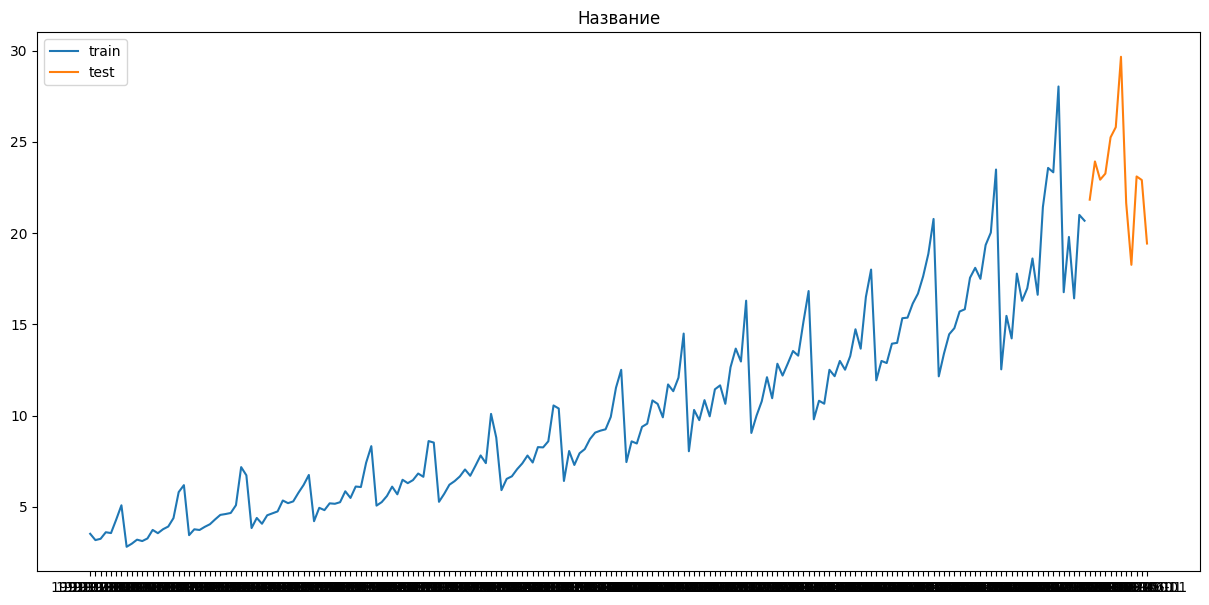

In [56]:
plt.title('Название')
plt.plot(data_train, label='train')
plt.plot(data_test, label='test')
plt.legend();

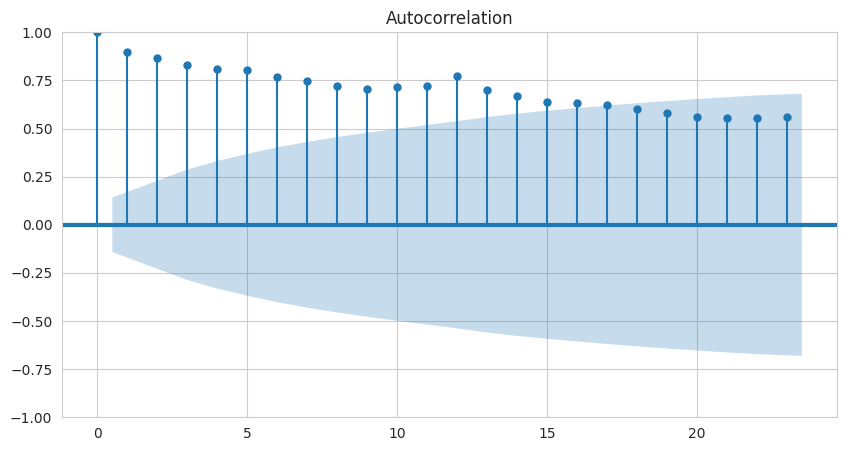

In [45]:
# Проверим, есть ли недельная сезонность.
rcParams['figure.figsize'] = 10, 5
with sns.axes_style('whitegrid'):
    statsmodels.graphics.tsaplots.plot_acf(data_train, lw=3)

Зададим метрики качаства моделей: MSE, MAE, MAPE. Зададим функцию, которая будет вычислять метрики качества моделей и записывать их в таблицу.

MAPE (mean absolute percentage error) — это средняя абсолютная ошибка нашего прогноза. Пусть $y_{i}$ — это показатель, а $\hat{y_{i}}$ — это соответствущий этой величине прогноз нашей модели. Тогда $e_{i} = y_{i} - \hat{y_{i}}$ — это ошибка прогноза, a $p_{i} =\frac{e_{i}}{y_{i}}$ — это относительная ошибка прогноза.
$MAPE = mean(|p_{i}|)$

MAPE часто используется для оценки качества, поскольку эта величина относительная и по ней можно сравнивать качество даже на различных наборах данных.

Кроме того, бывает полезно смотреть и на абсолютную ошибку MAE - mean absolute error, чтобы понимать, на сколько ошибается модель в абсолютных величинах.
$MAE = mean(|e_{i}|)$

In [14]:
compare_table = None


def add_results_in_comparison_table(method: str, y_true, y_forecast) -> pd.DataFrame:
    """
    Добавляет новую строчку в таблицу compare_table с результатами текущей модели.
    Если ранее модель была уже добавлена в таблицу, то старая строчка перезапишется на новую.
    
    Параметры:
    - method: имя модели
    - y_true: истинные значения
    - y_forecast: предсказанные значения.
    """
    
    # Обращаемся к глобальной переменной
    global compare_table
    
    # Считаем метрики
    result_row = {
        'method': method,
        "MSE": mean_squared_error(y_true=y_true, y_pred=y_forecast),
        "MAE": mean_absolute_error(y_true=y_true, y_pred=y_forecast),
        "MAPE": mean_absolute_percentage_error(y_true=y_true, y_pred=y_forecast)
    }
    
    # Записываем результат в таблицу
    if compare_table is None:
        compare_table = pd.DataFrame([result_row])
    else:
        if method in list(compare_table['method']):
            compare_table = compare_table[compare_table['method'] != method]

        compare_table = pd.concat([compare_table, pd.DataFrame([result_row])])
        compare_table.index = np.arange(len(compare_table))
    return compare_table


def mean_absolute_percentage_error(y_true, y_pred) -> float: 
    """Считает MAPE для y_true и y_pred"""
    
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

Prophet – модель, разработанная Facebook для предсказания временных рядов.
Для начала подготовим данные, чтобы их можно было передать модели.
Модель для обучения принимает на вход датасет из 2 колонок:
ds — дата
y — временой ряд

In [16]:
#или использоать: make_future_dataframehelper:

prophet_train_df = pd.DataFrame(data_train)
prophet_train_df.columns = ['y'] #колонка value переименовать в Y
prophet_train_df['ds'] = prophet_train_df.index #добавили ds

In [17]:
prophet_train_df

,y,ds
date,,
1991-07-01,3.526591,1991-07-01
1991-08-01,3.180891,1991-08-01
1991-09-01,3.252221,1991-09-01
1991-10-01,3.611003,1991-10-01
1991-11-01,3.565869,1991-11-01
...,...,...
2007-02-01,16.763869,2007-02-01
2007-03-01,19.792754,2007-03-01
2007-04-01,16.427305,2007-04-01


In [57]:
# интервал 95%
prophet_model = Prophet(interval_width=0.95)
prophet_model.fit(prophet_train_df)# !!!!!!обучили

13:22:57 - cmdstanpy - INFO - Chain [1] start processing
13:22:57 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
prophet_model = Prophet(
    # Сезонность
    daily_seasonality=False,          # Дневная сезонность
    weekly_seasonality=True,         # Недельная сезонность
    yearly_seasonality=True,         # Годовая сезонность
    
    # Режим сезонности
    seasonality_mode='multiplicative',     # 'additive' или 'multiplicative' 
    
    # Чувствительность к изменениям
    changepoint_prior_scale=0.05,    # Чувствительность к изменениям тренда
    seasonality_prior_scale=10.0,    # Регуляризация сезонности
    holidays_prior_scale=10.0,       # Регуляризация праздников
    
    # Доверительный интервал
    interval_width=0.95,             # Ширина доверительного интервала
    
    # Количество точек изменения тренда
    n_changepoints=25,               # Количество потенциальных точек изменения
    
    # Диапазон точек изменения
    changepoint_range=0.3            # Доля данных для поиска изменений
)

prophet_mod_fit =  prophet_model.fit(prophet_train_df)# !!!!!!обучили

14:10:58 - cmdstanpy - INFO - Chain [1] start processing
14:10:59 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
prophet_mod_fit.params,

(OrderedDict([('lp__', array([[634.58995]])),
              ('k', array([[0.35688665]])),
              ('m', array([[0.11583056]])),
              ('delta',
               array([[-1.1416665e-09,  6.3025665e-09,  3.6125220e-10, -3.2130703e-08,
                        6.3691340e-09,  9.6012226e-09,  2.1807702e-05,  8.0842729e-05,
                        6.7013116e-06,  7.2155758e-03,  3.0034711e-02,  6.9471523e-02,
                        9.6969366e-02,  5.9433982e-02,  6.9089955e-04,  1.0510906e-06,
                        5.8531747e-08,  5.4683173e-09, -4.5196374e-09, -9.1290936e-09,
                       -1.9451007e-08,  5.3493822e-09,  3.6108198e-03,  2.3836930e-01,
                        2.6939321e-01]])),
              ('sigma_obs', array([[0.02037378]])),
              ('beta',
               array([[-0.10586569,  0.0775969 , -0.1211927 ,  0.00544853, -0.08848491,
                        0.27267605,  0.16303892,  0.05782468,  0.02980142, -0.18623067,
                        0.

In [ ]:
plt.plot(prophet_mod_fit.)

TypeError: 'collections.OrderedDict' object is not callable

In [107]:
# ++++прогноз тестирую !!!!!этот вроде раельны прогноз
future = prophet_model.make_future_dataframe(
    periods=len(data_test), freq='ME', include_history=False
)

y_prophet_forecast = prophet_model.predict(future)

In [61]:
# предсказание с этими настройками рисует линию
future = prophet_model.make_future_dataframe(
    periods=len(data_test), freq='D', include_history=False
)

y_prophet_forecast = prophet_model.predict(future)

In [28]:
# самое интерсное yhat_lower  yhat_upper (верхний нижний интервалы) yhat (среднее значение)
y_prophet_forecast,

(            ds      trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
 0   1991-07-01   3.247702    2.005708    4.259820     3.247702     3.247702   
 1   1991-08-01   3.301056    2.156387    4.386487     3.301056     3.301056   
 2   1991-09-01   3.354410    2.072983    4.352958     3.354410     3.354410   
 3   1991-10-01   3.406044    2.566762    4.783482     3.406044     3.406044   
 4   1991-11-01   3.459398    2.633615    4.964921     3.459398     3.459398   
 ..         ...        ...         ...         ...          ...          ...   
 199 2008-01-31  22.146817   17.659503   19.961101    22.086174    22.214017   
 200 2008-02-29  22.305158   18.756054   20.998816    22.232156    22.383356   
 201 2008-03-31  22.474419   15.937025   18.263495    22.385674    22.564773   
 202 2008-04-30  22.638220   21.466887   23.744711    22.540332    22.740286   
 203 2008-05-31  22.807482   20.765237   23.001578    22.693432    22.926473   
 
      multiplicative_terms  multiplica

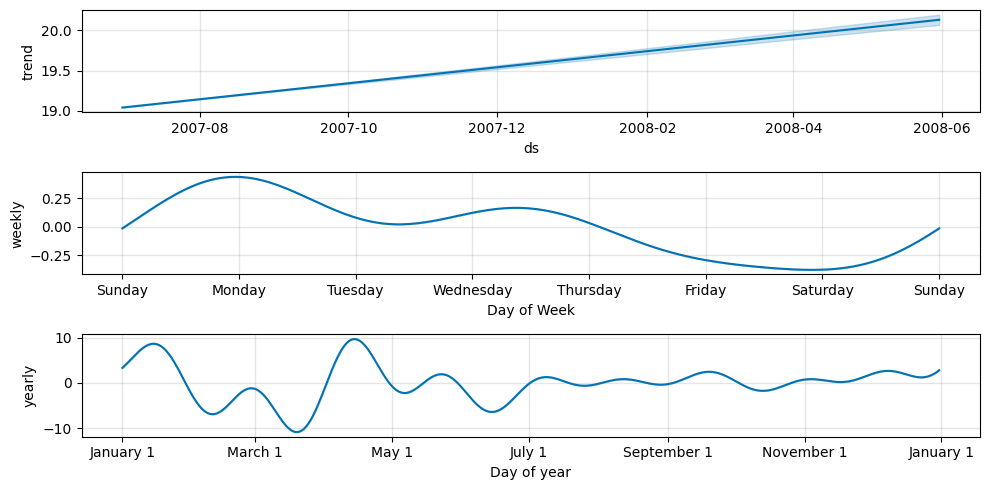

In [108]:
# Модель для каждой даты раскладывает свое предсказание на компоненты.
# из таблицы строим прогнозные тренд сезонность, ошибки
prophet_model.plot_components(y_prophet_forecast, figsize=(10, 5))
plt.show()


In [30]:
def plot_results(y_to_train, y_to_test, y_forecast, plot_conf_int=True,
                 left_bound=None, right_bound=None):
                 
    plt.figure(figsize=(15, 5))
    plt.title('Название 1', fontsize=15)
    plt.plot(y_to_train, label='train')
    plt.plot(y_to_test, label='test')
    plt.plot(y_to_test.index, y_forecast, label='prediction')
    if plot_conf_int:
        plt.fill_between(y_to_test.index, 
                         left_bound, right_bound, 
                         alpha=0.3, color='grey',
                         label='conf.int')
    plt.legend()
    plt.show()

In [31]:
data_test.index

Index(['2007-07-01', '2007-08-01', '2007-09-01', '2007-10-01', '2007-11-01',
       '2007-12-01', '2008-01-01', '2008-02-01', '2008-03-01', '2008-04-01',
       '2008-05-01', '2008-06-01'],
      dtype='object', name='date')

In [35]:
data_test

date
2007-07-01    21.834890
2007-08-01    23.930204
2007-09-01    22.930357
2007-10-01    23.263340
2007-11-01    25.250030
2007-12-01    25.806090
2008-01-01    29.665356
2008-02-01    21.654285
2008-03-01    18.264945
2008-04-01    23.107677
2008-05-01    22.912510
2008-06-01    19.431740
Name: value, dtype: float64

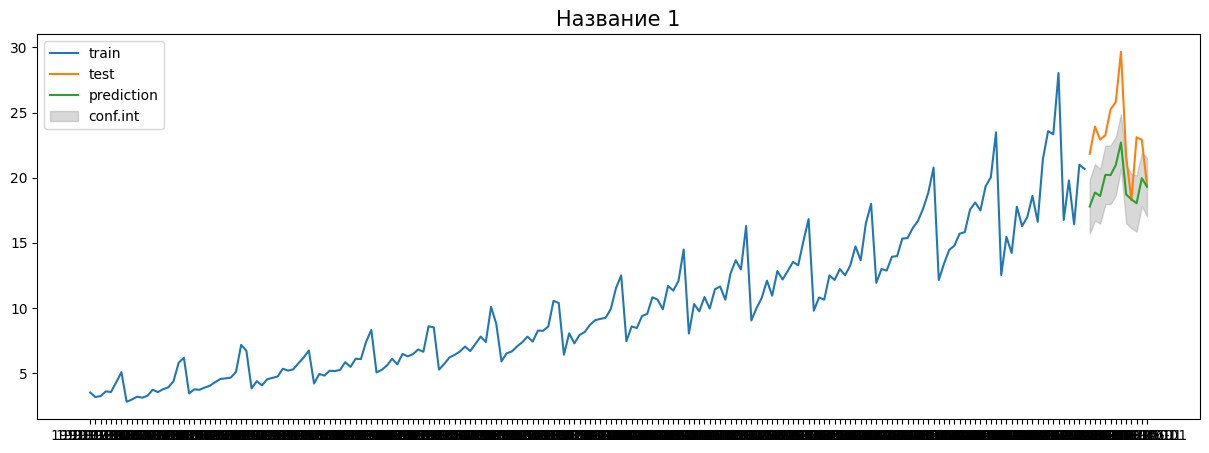

In [109]:
plot_results(data_train, data_test, y_prophet_forecast['yhat'], plot_conf_int=True,
             left_bound=y_prophet_forecast['yhat_lower'],
             right_bound=y_prophet_forecast['yhat_upper'])

In [79]:
add_results_in_comparison_table('Prophet', data_test, y_prophet_forecast['yhat'])

,method,MSE,MAE,MAPE
0,Prophet,17.195981,3.725773,15.93755


In [95]:
# чем хорош профит что легко добавить экзогенные факторы
prophet_model_with_holidays = Prophet(interval_width=0.95)
prophet_model_with_holidays.add_country_holidays(country_name='US')
prophet_model_with_holidays.fit(prophet_train_df)

13:58:53 - cmdstanpy - INFO - Chain [1] start processing
13:58:53 - cmdstanpy - INFO - Chain [1] done processing


In [65]:
prophet_model_with_holidays.train_holiday_names,

(0                  New Year's Day
 1                    Memorial Day
 2                Independence Day
 3                       Labor Day
 4                Thanksgiving Day
 5                   Christmas Day
 6      Martin Luther King Jr. Day
 7           Washington's Birthday
 8                    Columbus Day
 9                    Veterans Day
 10    Independence Day (observed)
 11      New Year's Day (observed)
 12       Christmas Day (observed)
 13        Veterans Day (observed)
 dtype: object,)

In [110]:
prophet_model_with_holidays = Prophet(
    # Сезонность
    daily_seasonality=False,          # Дневная сезонность
    weekly_seasonality=True,         # Недельная сезонность
    yearly_seasonality=True,         # Годовая сезонность
    
    # Режим сезонности
    seasonality_mode='multiplicative',     # 'additive' или 'multiplicative'
    
    # Чувствительность к изменениям
    changepoint_prior_scale=0.05,    # Чувствительность к изменениям тренда
    seasonality_prior_scale=10.0,    # Регуляризация сезонности
    holidays_prior_scale=100.0,       # Регуляризация праздников
    
    # Доверительный интервал
    interval_width=0.95,             # Ширина доверительного интервала
    
    # Количество точек изменения тренда
    n_changepoints=25,               # Количество потенциальных точек изменения
    
    # Диапазон точек изменения
    changepoint_range=0.3            # Доля данных для поиска изменений
)

In [111]:
prophet_model_with_holidays.add_country_holidays(country_name='US')
prophet_model_with_holidays.fit(prophet_train_df)

14:14:28 - cmdstanpy - INFO - Chain [1] start processing
14:14:28 - cmdstanpy - INFO - Chain [1] done processing


In [101]:
prophet_model_with_holidays.train_holiday_names.head(50)

0                  New Year's Day
1                    Memorial Day
2                Independence Day
3                       Labor Day
4                Thanksgiving Day
5                   Christmas Day
6      Martin Luther King Jr. Day
7           Washington's Birthday
8                    Columbus Day
9                    Veterans Day
10    Independence Day (observed)
11      New Year's Day (observed)
12       Christmas Day (observed)
13        Veterans Day (observed)
dtype: object

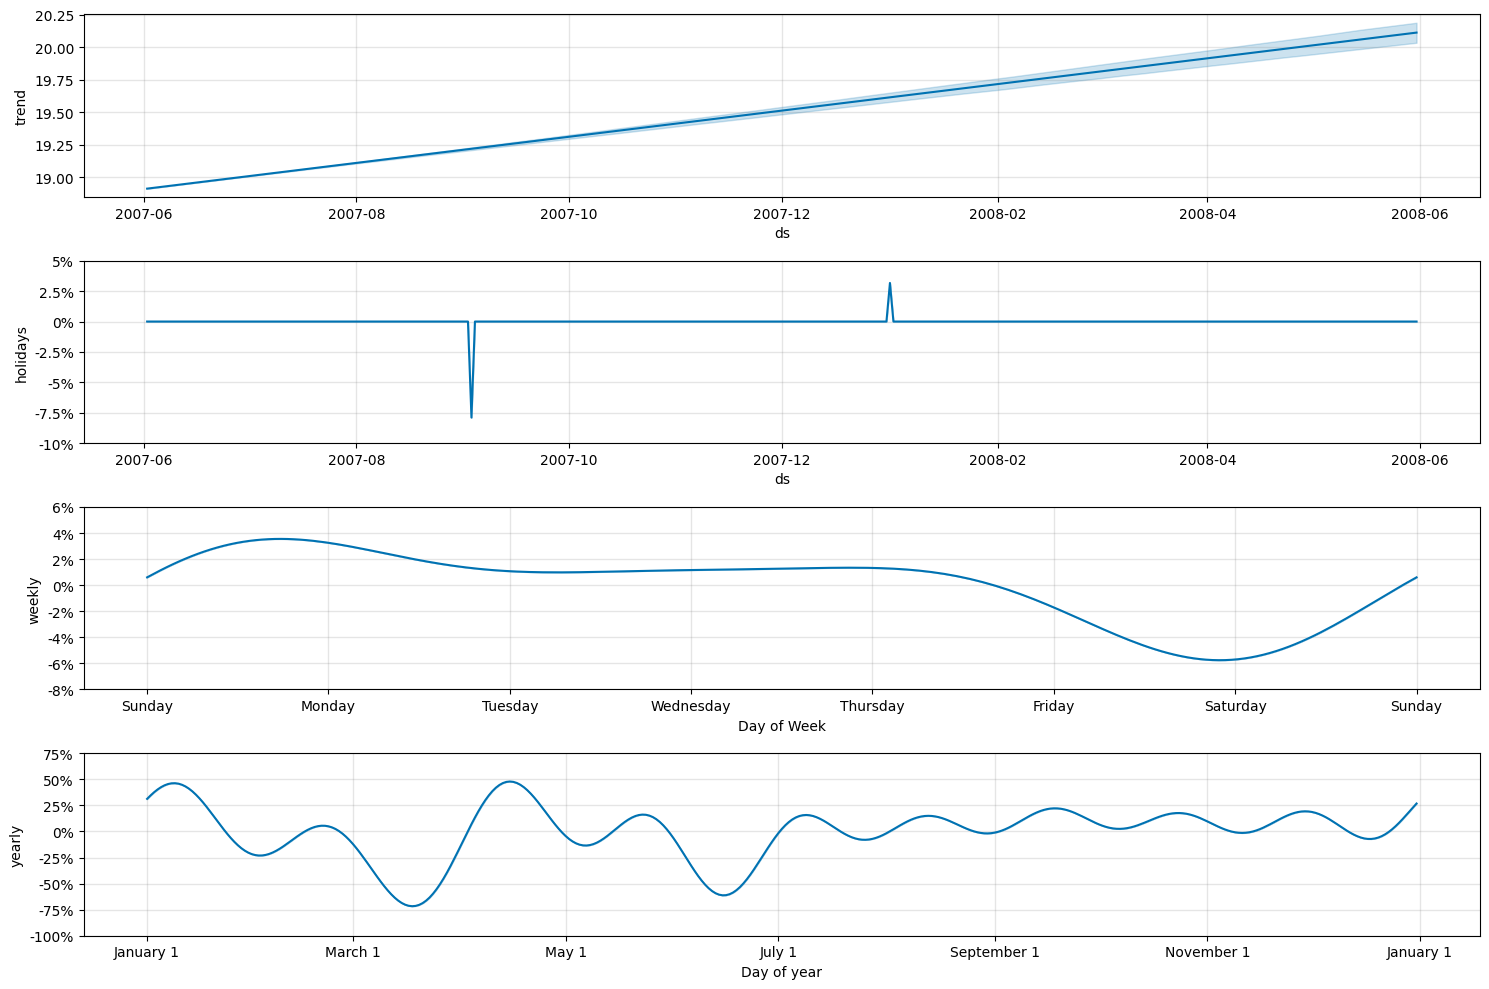

In [ ]:
#период 365 праздники учитывает
future = prophet_model_with_holidays.make_future_dataframe(
    periods=365, include_history=False
)
y_prophet_with_holidays_forecast = prophet_model_with_holidays.predict(future)

prophet_model_with_holidays.plot_components(y_prophet_with_holidays_forecast, figsize=(15, 10))
plt.show()

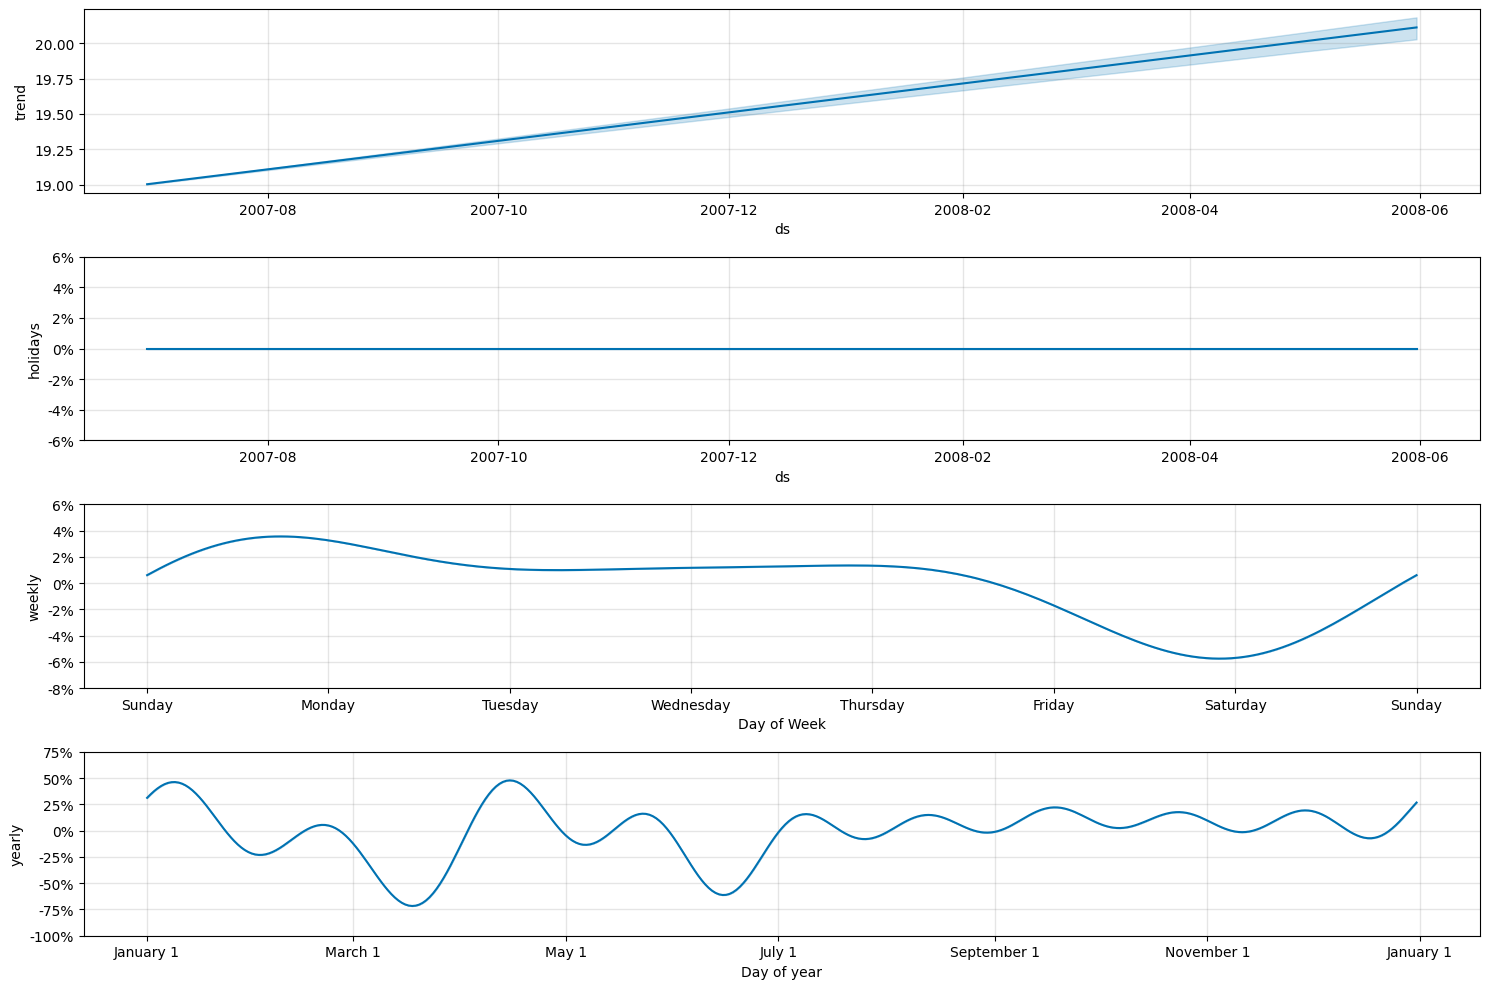

In [ ]:
# праздники не учитывает МАЕ тако же как и модель вверху
future = prophet_model_with_holidays.make_future_dataframe(
    periods=len(data_test), freq='ME', include_history=False
)
y_prophet_with_holidays_forecast = prophet_model_with_holidays.predict(future)

prophet_model_with_holidays.plot_components(y_prophet_with_holidays_forecast, figsize=(15, 10))
plt.show()

In [92]:
y_prophet_with_holidays_forecast 



,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Anniversary of the Great October Socialist Revolution,Anniversary of the Great October Socialist Revolution_lower,Anniversary of the Great October Socialist Revolution_upper,Christmas Day,...,holidays,holidays_lower,holidays_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2007-06-02,20.213537,17.422923,20.610688,20.213537,20.213537,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.151259,-1.151259,-1.151259,0.0,0.0,0.0,19.062278
1,2007-06-03,20.218259,16.871880,20.204716,20.218259,20.218259,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.572684,-1.572684,-1.572684,0.0,0.0,0.0,18.645575
2,2007-06-04,20.222980,16.574645,19.800844,20.222980,20.222980,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.987595,-1.987595,-1.987595,0.0,0.0,0.0,18.235385
3,2007-06-05,20.227702,16.269941,19.335317,20.227702,20.227702,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-2.386270,-2.386270,-2.386270,0.0,0.0,0.0,17.841431
4,2007-06-06,20.232423,15.871888,19.013897,20.232423,20.232423,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-2.759671,-2.759671,-2.759671,0.0,0.0,0.0,17.472752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2008-05-27,21.913279,21.091958,24.262144,21.816617,22.016242,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.766067,0.766067,0.766067,0.0,0.0,0.0,22.679346
361,2008-05-28,21.918001,20.729750,24.011906,21.820713,22.021471,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.475621,0.475621,0.475621,0.0,0.0,0.0,22.393622
362,2008-05-29,21.922722,20.529963,23.663639,21.824809,22.026700,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.139933,0.139933,0.139933,0.0,0.0,0.0,22.062656
363,2008-05-30,21.927444,20.227180,23.289662,21.828905,22.031929,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.232098,-0.232098,-0.232098,0.0,0.0,0.0,21.695346


In [122]:
y_prophet_with_holidays_forecast['yhat']

0      16.088866
1      16.322354
2      15.831724
3      14.412220
4      13.427026
         ...    
360    22.553448
361    22.012141
362    21.370501
363    19.982002
364    18.308138
Name: yhat, Length: 365, dtype: float64

In [130]:
prophet_boxcox_preidction = y_prophet_with_holidays_forecast.yhat[204:216]
prophet_boxcox_preidction

204    19.367053
205    20.364607
206    20.489207
207    21.122448
208    21.822340
209    21.936387
210    21.888371
211    23.870538
212    25.134109
213    26.053714
214    26.141147
215    26.816085
Name: yhat, dtype: float64

ValueError: 'x' has size 12, but 'y1' has an unequal size of 365

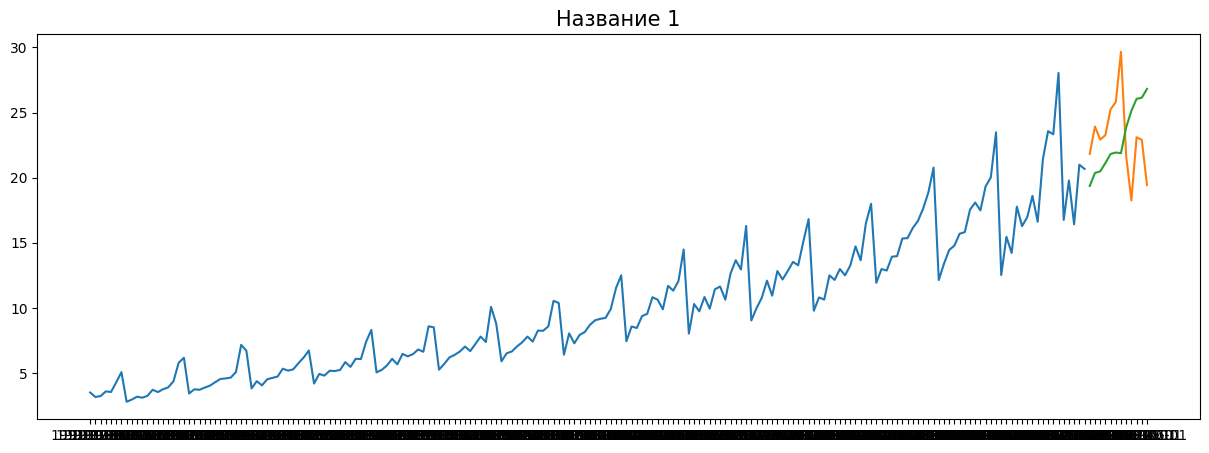

In [131]:
#prophet_boxcox_preidction = y_prophet_with_holidays_forecast.yhat[-test_size:]

plot_results(data_train, data_test, prophet_boxcox_preidction, plot_conf_int=True,
             left_bound=y_prophet_with_holidays_forecast['yhat_lower'],
             right_bound=y_prophet_with_holidays_forecast['yhat_upper'])

ValueError: x and y must have same first dimension, but have shapes (12,) and (365,)

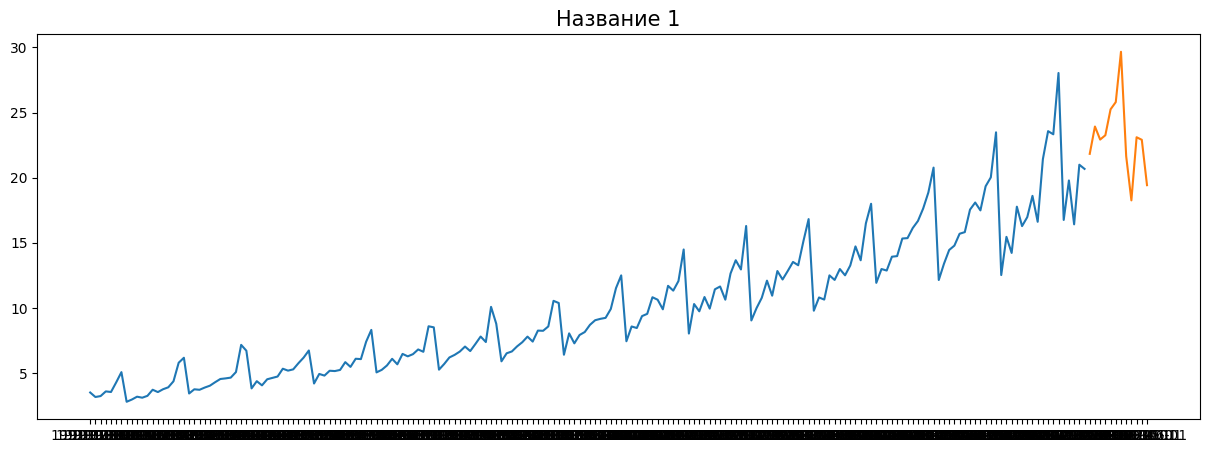

In [104]:
prophet_boxcox_preidction = y_prophet_with_holidays_forecast['yhat']

plot_results(data_train, data_test, prophet_boxcox_preidction, plot_conf_int=True,
             left_bound=y_prophet_with_holidays_forecast['yhat_lower'],
             right_bound=y_prophet_with_holidays_forecast['yhat_upper'])

In [132]:
add_results_in_comparison_table('Prophet + holidays', data_test, y_prophet_with_holidays_forecast['yhat'])

ValueError: Found input variables with inconsistent numbers of samples: [12, 365]